<h1 style="text-align:center; color:#2E4057;">🌲 Random Forest ile Kredi Kartı Temerrüt (Default) Analizi</h1>
<h3 style="text-align:center; color:#555;">Default of Credit Card Clients Dataset (UCI, Taiwan)</h3>

Bu defterde, Tayvan'daki kredi kartı müşterilerine ait veriler üzerinde **Random Forest** algoritması ile bir sonraki ay ödeme temerrüdüne düşüp düşmeyeceklerini tahmin eden bir sınıflandırma modeli kuracağız. Veri seti **dengesiz (imbalanced)** olduğu için bu duruma özel değerlendirme adımlarına da yer vereceğiz.

## 📋 Veri Seti Değişken Sözlüğü

| Değişken | Açıklama | Tür |
|---|---|---|
| `LIMIT_BAL` | Verilen kredi limiti (NT dolar) | Sayısal |
| `SEX` | Cinsiyet (1=erkek, 2=kadın) | Kategorik |
| `EDUCATION` | Eğitim seviyesi | Kategorik |
| `MARRIAGE` | Medeni durum | Kategorik |
| `AGE` | Yaş | Sayısal |
| `PAY_0..PAY_6` | Geçmiş ödeme durumu (gecikme ayı sayısı) | Sayısal |
| `BILL_AMT1..6` | Geçmiş ekstre tutarları | Sayısal |
| `PAY_AMT1..6` | Geçmiş ödeme tutarları | Sayısal |
| `default payment next month` | Hedef değişken (1=temerrüt, 0=temerrüt yok) | Kategorik (0/1) |

## 1️⃣ Kütüphanelerin İçe Aktarılması

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
                              classification_report, RocCurveDisplay)

pd.set_option('display.max_columns', 30)
sns.set_style('whitegrid')
RANDOM_STATE = 42

## 2️⃣ Veri Setinin Yüklenmesi ve Keşfi

In [2]:
df = pd.read_excel('default of credit card clients.xls', header=1)
df = df.rename(columns={'default payment next month': 'DEFAULT'})
df = df.drop(columns=['ID'])
df.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT
0,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [3]:
print(f"📐 Boyut : {df.shape[0]:,} satır × {df.shape[1]} sütun")

📐 Boyut : 30,000 satır × 24 sütun


In [4]:
print("❓ Eksik Değer Analizi:")
print(df.isnull().sum().sum())

❓ Eksik Değer Analizi:
0


In [5]:
print("📊 İstatistiksel Özet:")
df.describe().T

📊 İstatistiksel Özet:


,count,mean,std,min,25%,50%,75%,max
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_0,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0
PAY_5,30000.0,-0.266200,1.133187,-2.0,-1.00,0.0,0.00,8.0


In [6]:
print("🏷️  Hedef Değişken (DEFAULT) Dağılımı:")
print(df['DEFAULT'].value_counts())
print(df['DEFAULT'].value_counts(normalize=True).round(3))

🏷️  Hedef Değişken (DEFAULT) Dağılımı:
DEFAULT
0    23364
1     6636
Name: count, dtype: int64
DEFAULT
0    0.779
1    0.221
Name: proportion, dtype: float64


## 3️⃣ Görsel Keşifsel Veri Analizi (EDA)

/tmp/ipykernel_610/1886168895.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='DEFAULT', y='LIMIT_BAL', data=df, ax=axes[1], palette=['#2E4057', '#D64550'])


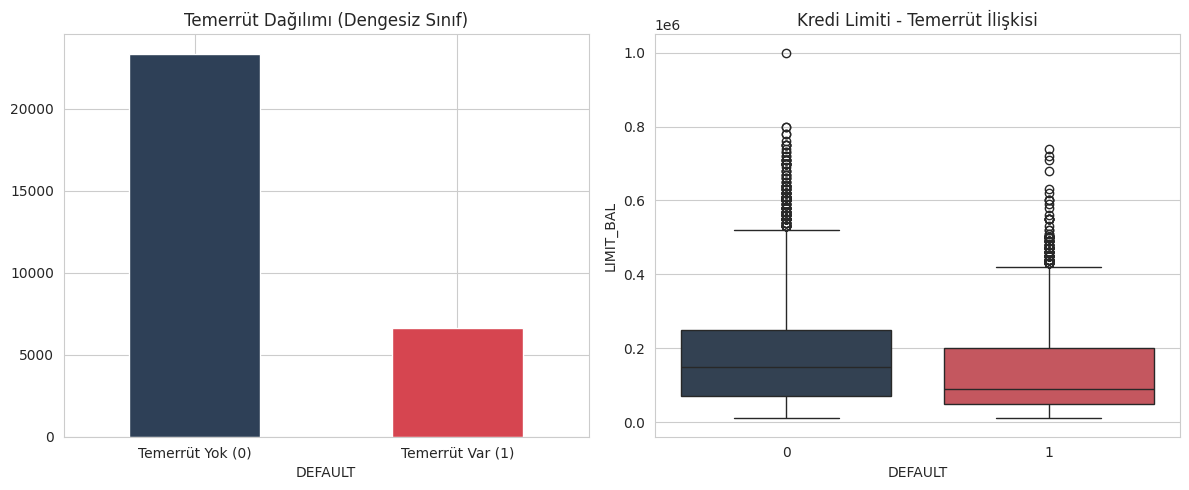

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
df['DEFAULT'].value_counts().plot(kind='bar', ax=axes[0], color=['#2E4057', '#D64550'])
axes[0].set_title('Temerrüt Dağılımı (Dengesiz Sınıf)')
axes[0].set_xticklabels(['Temerrüt Yok (0)', 'Temerrüt Var (1)'], rotation=0)

sns.boxplot(x='DEFAULT', y='LIMIT_BAL', data=df, ax=axes[1], palette=['#2E4057', '#D64550'])
axes[1].set_title('Kredi Limiti - Temerrüt İlişkisi')
plt.tight_layout()
plt.show()

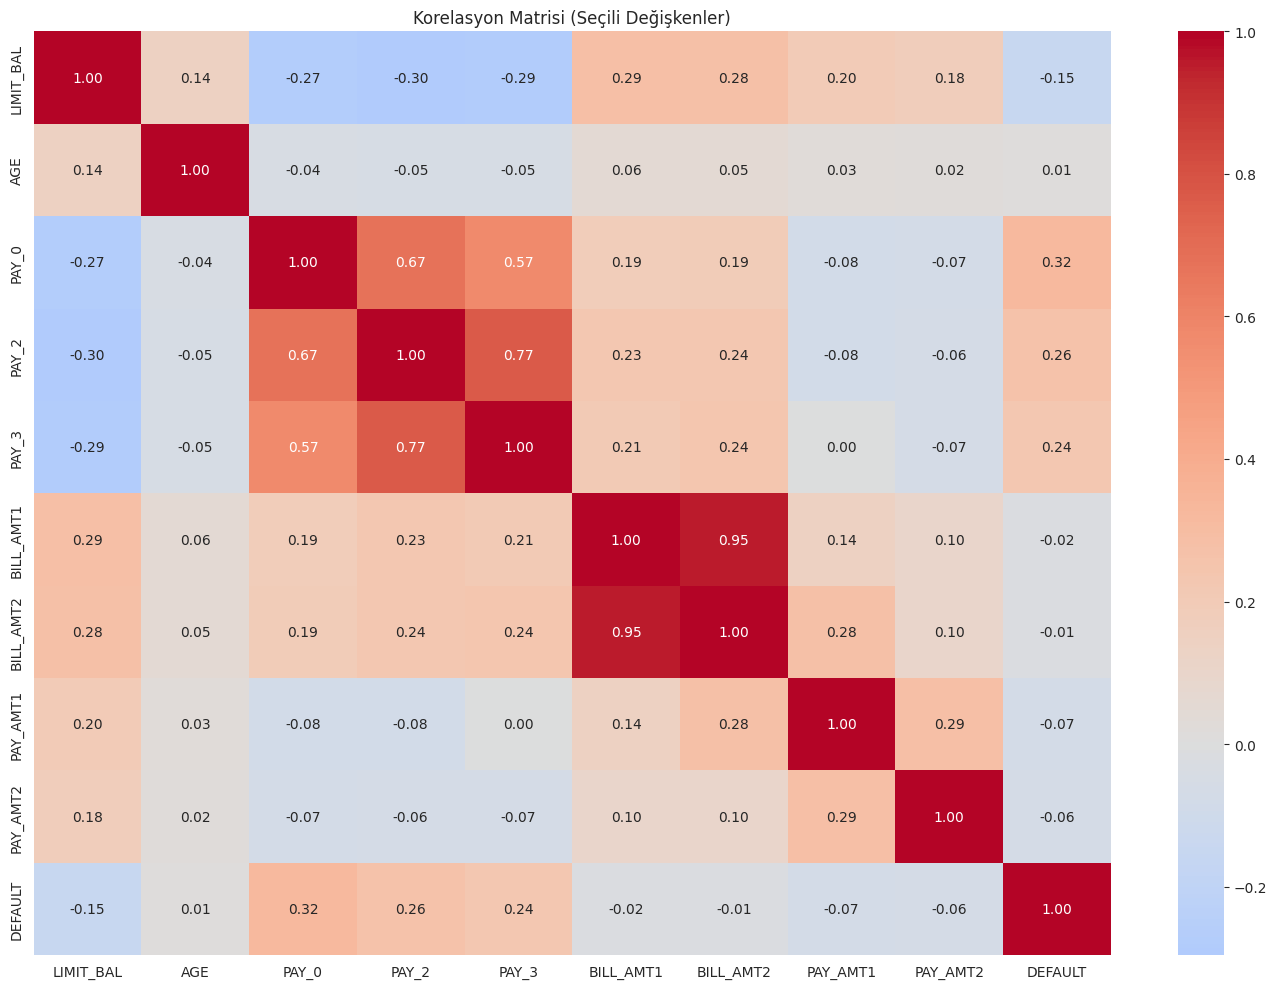

In [8]:
plt.figure(figsize=(14, 10))
corr_cols = ['LIMIT_BAL', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'BILL_AMT1', 'BILL_AMT2',
             'PAY_AMT1', 'PAY_AMT2', 'DEFAULT']
sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Korelasyon Matrisi (Seçili Değişkenler)')
plt.tight_layout()
plt.show()

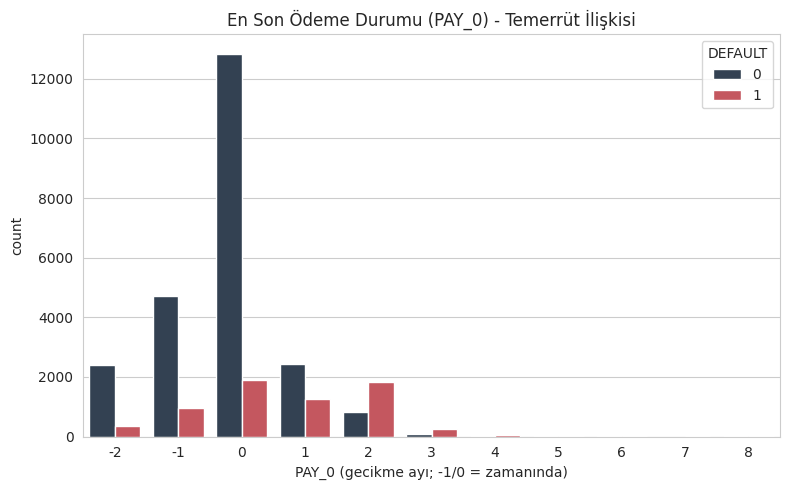

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(x='PAY_0', hue='DEFAULT', data=df, palette=['#2E4057', '#D64550'], ax=ax)
ax.set_title('En Son Ödeme Durumu (PAY_0) - Temerrüt İlişkisi')
ax.set_xlabel('PAY_0 (gecikme ayı; -1/0 = zamanında)')
plt.tight_layout()
plt.show()

## 4️⃣ Veri Ön İşleme

In [10]:
df_clean = df.copy()
df_clean['EDUCATION'] = df_clean['EDUCATION'].replace({0: 4, 5: 4, 6: 4})
df_clean['MARRIAGE'] = df_clean['MARRIAGE'].replace({0: 3})

X = df_clean.drop(columns=['DEFAULT'])
y = df_clean['DEFAULT']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"Eğitim seti: {X_train.shape}, Test seti: {X_test.shape}")

Eğitim seti: (24000, 23), Test seti: (6000, 23)


## 5️⃣ Random Forest Sınıflandırma – Temerrüt Tahmini

In [11]:
rf_clf = RandomForestClassifier(
    n_estimators=150,
    max_depth=8,
    min_samples_leaf=20,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_clf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",150
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",20
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [12]:
y_pred = rf_clf.predict(X_test)
y_proba = rf_clf.predict_proba(X_test)[:, 1]

print(f"Doğruluk (Accuracy) : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision            : {precision_score(y_test, y_pred):.4f}")
print(f"Recall               : {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score             : {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC              : {roc_auc_score(y_test, y_proba):.4f}")

Doğruluk (Accuracy) : 0.7765
Precision            : 0.4956
Recall               : 0.5953
F1-Score             : 0.5409
ROC-AUC              : 0.7742


In [13]:
print(classification_report(y_test, y_pred, target_names=['Temerrüt Yok', 'Temerrüt Var']))

              precision    recall  f1-score   support

Temerrüt Yok       0.88      0.83      0.85      4673
Temerrüt Var       0.50      0.60      0.54      1327

    accuracy                           0.78      6000
   macro avg       0.69      0.71      0.70      6000
weighted avg       0.79      0.78      0.78      6000



/usr/local/lib/python3.12/dist-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


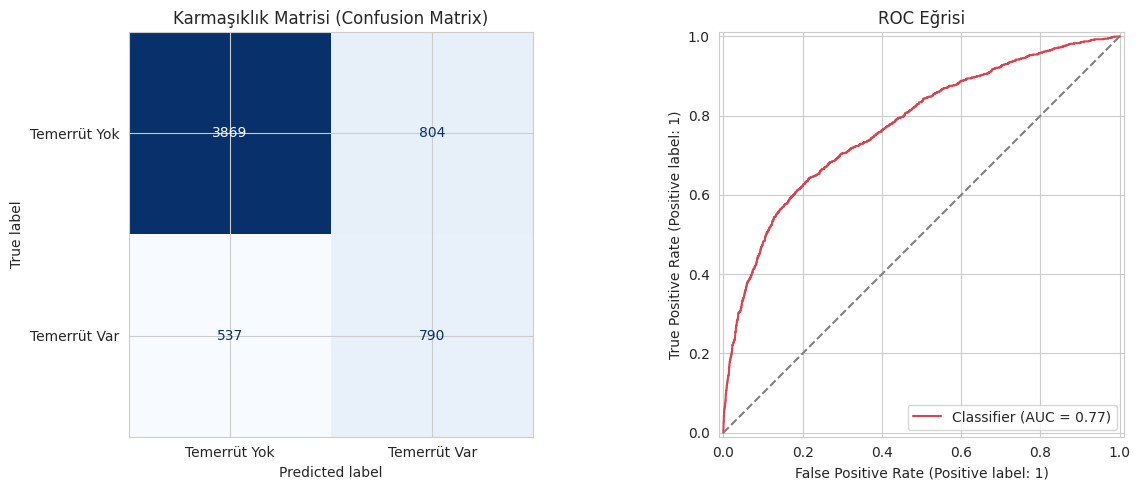

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Temerrüt Yok', 'Temerrüt Var']).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Karmaşıklık Matrisi (Confusion Matrix)')

RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1], color='#D64550')
axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[1].set_title('ROC Eğrisi')
plt.tight_layout()
plt.show()

## 6️⃣ Özellik Önemi (Feature Importance)

/tmp/ipykernel_610/4255960310.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feat_imp, palette='viridis')


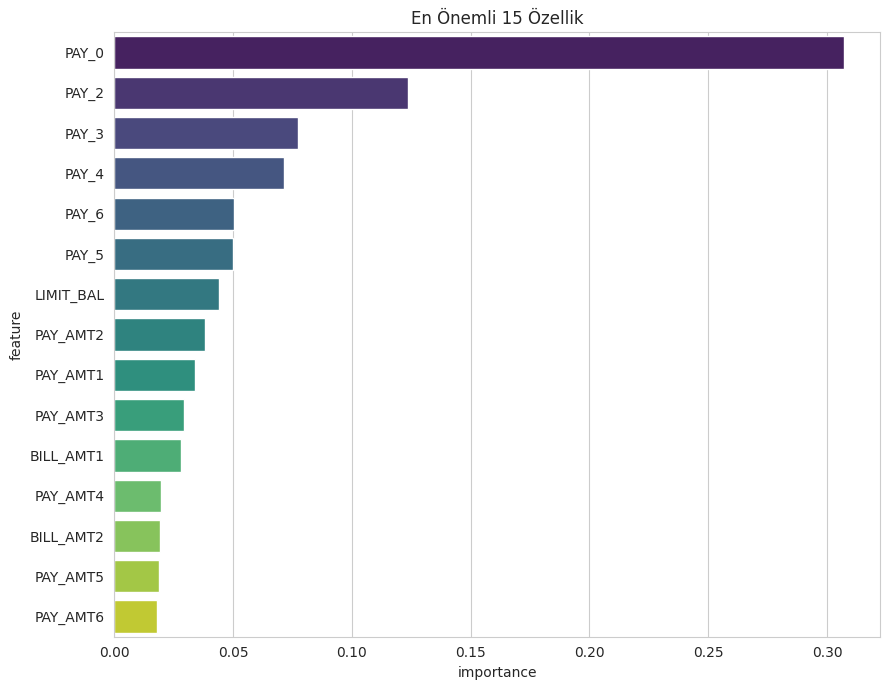

In [15]:
feat_imp = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_clf.feature_importances_
}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(9, 7))
sns.barplot(x='importance', y='feature', data=feat_imp, palette='viridis')
plt.title('En Önemli 15 Özellik')
plt.tight_layout()
plt.show()

## 7️⃣ Hiperparametre Optimizasyonu (Grid Search CV)

In [16]:
param_grid = {
    'n_estimators': [100, 150],
    'max_depth': [6, 8],
    'min_samples_leaf': [20, 30]
}

grid_search = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
    param_grid,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

print(f"En iyi parametreler: {grid_search.best_params_}")
print(f"En iyi CV ROC-AUC   : {grid_search.best_score_:.4f}")

En iyi parametreler: {'max_depth': 8, 'min_samples_leaf': 30, 'n_estimators': 150}
En iyi CV ROC-AUC   : 0.7800


In [17]:
best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test)
y_proba_best = best_rf.predict_proba(X_test)[:, 1]

print(f"Optimize Model ROC-AUC : {roc_auc_score(y_test, y_proba_best):.4f}")
print(f"Optimize Model F1      : {f1_score(y_test, y_pred_best):.4f}")

Optimize Model ROC-AUC : 0.7737
Optimize Model F1      : 0.5411


## 8️⃣ Çapraz Doğrulama (5-Fold Cross Validation)

In [18]:
cv_scores = cross_val_score(best_rf, X, y, cv=3, scoring='roc_auc')
print(f"5-Fold CV ROC-AUC skorları: {np.round(cv_scores, 4)}")
print(f"Ortalama: {cv_scores.mean():.4f}  |  Std: {cv_scores.std():.4f}")

5-Fold CV ROC-AUC skorları: [0.7597 0.7872 0.7874]
Ortalama: 0.7781  |  Std: 0.0130


## 9️⃣ Sonuç ve Değerlendirme

### 📈 Random Forest Sınıflandırma Modeli — Kredi Kartı Temerrüt Tahmini

- Veri seti **dengesiz** olduğu için `class_weight='balanced'` parametresi ve **ROC-AUC / F1-Score** metrikleri temel değerlendirme ölçütü olarak kullanılmıştır (yalnızca Accuracy'ye güvenilmemiştir).
- En güçlü öngörücüler arasında `PAY_0` (en son ödeme gecikmesi), `LIMIT_BAL` (kredi limiti) ve `BILL_AMT1` (güncel ekstre tutarı) öne çıkmaktadır.
- Grid Search ile optimize edilen model, varsayılan parametrelere göre benzer veya daha iyi ROC-AUC skoru üretmiştir.
- 5-Fold çapraz doğrulama sonuçları, modelin farklı veri bölmelerinde **tutarlı** performans sergilediğini göstermektedir.
- **Geliştirme Önerileri:** SMOTE gibi yeniden örnekleme teknikleri, farklı sınıflandırma eşiği (threshold) seçimi ve ek özellik mühendisliği (örn. ödeme/limit oranı) ile model performansı artırılabilir.